# 07 — Classical vs Multi-Agent: Confronto Diretto

**Obiettivo:** Confrontare quantitativamente i risultati delle due pipeline sulle stesse 567 rotte.

| Pipeline | Score | Label |
|---|---|---|
| Classical | `anomaly_score` (IF+LOF+Z+AE ensemble) | `anomaly_label` (ALTA/MEDIA/NORMALE) |
| Multi-Agent | `ensemble_score` (IF+LOF+Z+AE ensemble) | `risk_label` (ALTA/MEDIA/NORMALE) |

Le feature di input sono **identiche** (stessa logica, stesso dataset). La differenza è l'architettura.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr, pearsonr

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

ROOT = Path.cwd().parent if (Path.cwd().parent / 'data').exists() else Path.cwd()
PROC = ROOT / 'data' / 'processed'

cl = pd.read_csv(PROC / 'anomaly_results.csv')
ma = pd.read_csv(PROC / 'multiagent_anomalies_full.csv')
print(f'Classical:   {cl.shape}  | labels: {cl["anomaly_label"].value_counts().to_dict()}')
print(f'Multi-agent: {ma.shape} | labels: {ma["risk_label"].value_counts().to_dict()}')

Classical:   (567, 16)  | labels: {'NORMALE': 510, 'MEDIA': 40, 'ALTA': 17}
Multi-agent: (567, 81) | labels: {'NORMALE': 510, 'MEDIA': 40, 'ALTA': 17}


## 1. Join sulle rotte comuni

In [2]:
df = cl[['ROTTA','anomaly_score','anomaly_label','score_composito','rank']].merge(
    ma[['ROTTA','ensemble_score','risk_label','score_composito']].rename(
        columns={'score_composito':'score_composito_ma'}),
    on='ROTTA', how='inner'
)
print(f'Rotte in comune: {len(df)} su {len(cl)} classical / {len(ma)} multiagent')
df.head()

Rotte in comune: 567 su 567 classical / 567 multiagent


,ROTTA,anomaly_score,anomaly_label,score_composito,rank,ensemble_score,risk_label,score_composito_ma
0,ALG-MXP,0.5909,ALTA,0.484762,1,0.617093,NORMALE,0.548596
1,RAK-CIA,0.4793,ALTA,0.442287,2,0.462498,NORMALE,0.502221
2,HRG-NAP,0.4483,ALTA,0.153093,3,0.376581,NORMALE,0.215234
3,RAK-TSF,0.4475,ALTA,0.326172,4,0.577581,NORMALE,0.397681
4,CMN-BLQ,0.4424,ALTA,0.542542,5,0.860249,ALTA,0.634598


## 2. Correlazione degli score

Pearson  r = 0.3161  (p=1.27e-14)
Spearman r = 0.3625  (p=4.74e-19)


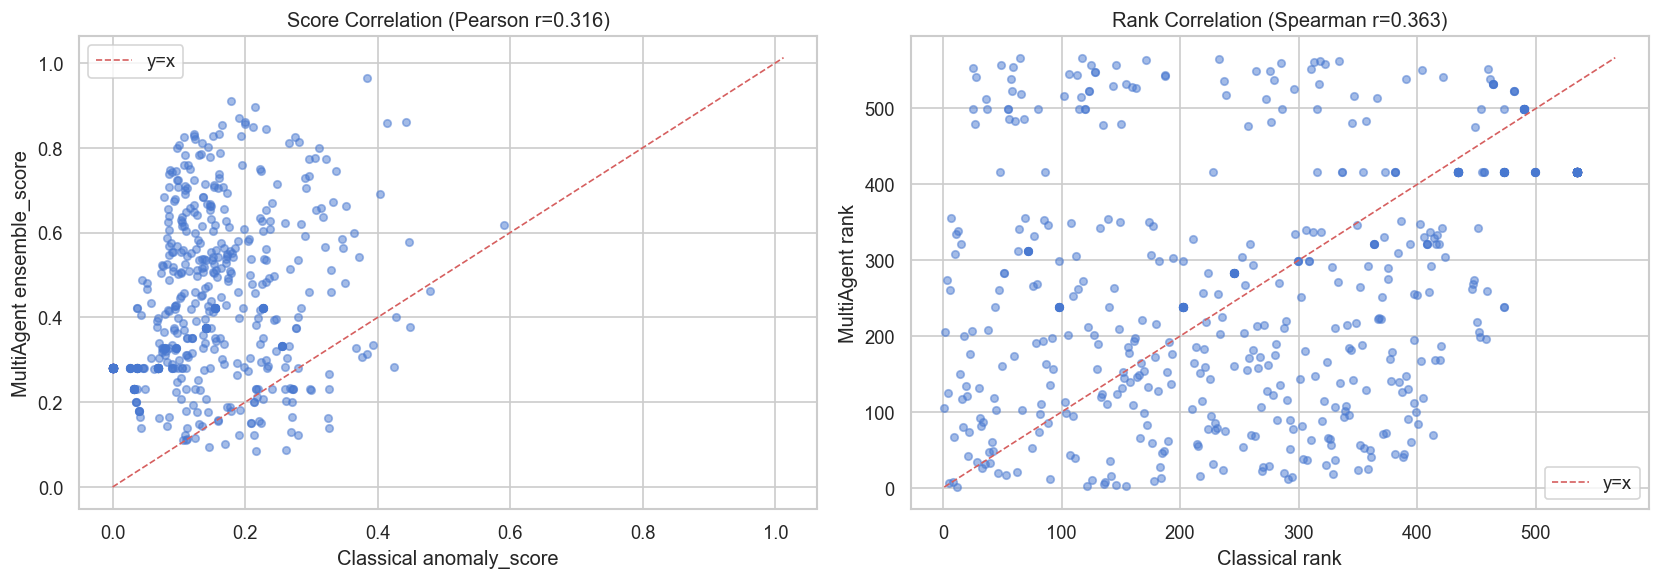

In [3]:
pearson_r,  p_p = pearsonr(df['anomaly_score'], df['ensemble_score'])
spearman_r, p_s = spearmanr(df['anomaly_score'], df['ensemble_score'])

print(f'Pearson  r = {pearson_r:.4f}  (p={p_p:.2e})')
print(f'Spearman r = {spearman_r:.4f}  (p={p_s:.2e})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter score
axes[0].scatter(df['anomaly_score'], df['ensemble_score'], alpha=0.5, s=20)
lim = [0, max(df['anomaly_score'].max(), df['ensemble_score'].max()) * 1.05]
axes[0].plot(lim, lim, 'r--', linewidth=1, label='y=x')
axes[0].set_xlabel('Classical anomaly_score')
axes[0].set_ylabel('MultiAgent ensemble_score')
axes[0].set_title(f'Score Correlation (Pearson r={pearson_r:.3f})')
axes[0].legend()

# Rank correlation
cl_rank = df['anomaly_score'].rank(ascending=False)
ma_rank = df['ensemble_score'].rank(ascending=False)
axes[1].scatter(cl_rank, ma_rank, alpha=0.5, s=20)
axes[1].plot([1, len(df)], [1, len(df)], 'r--', linewidth=1, label='y=x')
axes[1].set_xlabel('Classical rank')
axes[1].set_ylabel('MultiAgent rank')
axes[1].set_title(f'Rank Correlation (Spearman r={spearman_r:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Agreement delle label (Confusion Matrix)

Agreement complessivo: 84.0%

              precision    recall  f1-score   support

        ALTA       0.18      0.18      0.18        17
       MEDIA       0.20      0.20      0.20        40
     NORMALE       0.91      0.91      0.91       510

    accuracy                           0.84       567
   macro avg       0.43      0.43      0.43       567
weighted avg       0.84      0.84      0.84       567



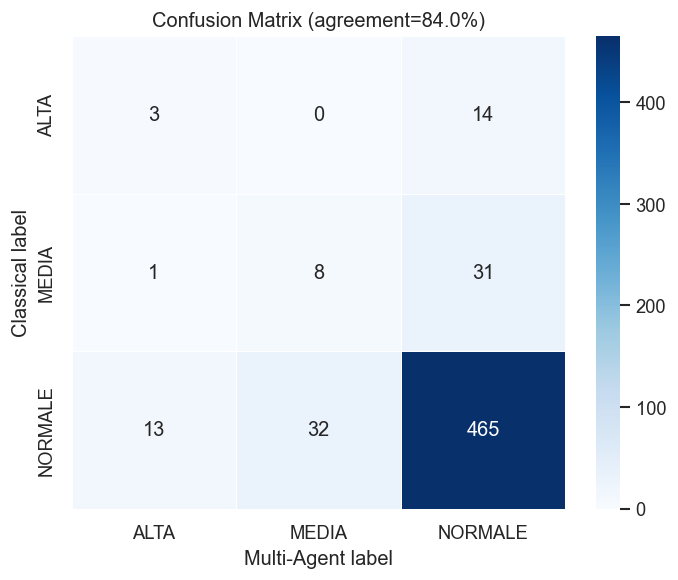

In [4]:
from sklearn.metrics import confusion_matrix, classification_report

order = ['ALTA', 'MEDIA', 'NORMALE']
cm = confusion_matrix(df['anomaly_label'], df['risk_label'], labels=order)
agreement = (df['anomaly_label'] == df['risk_label']).mean()

print(f'Agreement complessivo: {agreement:.1%}')
print()
print(classification_report(df['anomaly_label'], df['risk_label'], labels=order, zero_division=0))

plt.figure(figsize=(6, 5))
sns.heatmap(pd.DataFrame(cm, index=order, columns=order),
            annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.xlabel('Multi-Agent label')
plt.ylabel('Classical label')
plt.title(f'Confusion Matrix (agreement={agreement:.1%})')
plt.tight_layout()
plt.show()

## 4. Top 20 rotte: chi le vede come ALTA?

In [5]:
top_cl = set(df.nlargest(20, 'anomaly_score')['ROTTA'])
top_ma = set(df.nlargest(20, 'ensemble_score')['ROTTA'])
both   = top_cl & top_ma
only_cl = top_cl - top_ma
only_ma = top_ma - top_cl

print(f'Top-20 in comune: {len(both)} rotte ({len(both)/20:.0%})')
print(f'Solo nel classico: {sorted(only_cl)}')
print(f'Solo nel multiagent: {sorted(only_ma)}')

# Tabella comparativa top-20 union
union_rotte = top_cl | top_ma
comp = df[df['ROTTA'].isin(union_rotte)].copy()
comp['cl_rank'] = comp['anomaly_score'].rank(ascending=False, method='min').astype(int)
comp['ma_rank'] = comp['ensemble_score'].rank(ascending=False, method='min').astype(int)
comp['delta_score'] = (comp['ensemble_score'] - comp['anomaly_score']).round(4)
comp['in_top20_cl'] = comp['ROTTA'].isin(top_cl)
comp['in_top20_ma'] = comp['ROTTA'].isin(top_ma)
display_cols = ['ROTTA','anomaly_label','risk_label','anomaly_score','ensemble_score','delta_score','cl_rank','ma_rank','in_top20_cl','in_top20_ma']
comp[display_cols].sort_values('anomaly_score', ascending=False)

Top-20 in comune: 3 rotte (15%)
Solo nel classico: ['ALG-MXP', 'AMM-FCO', 'CAN-FCO', 'EVN-VCE', 'GIG-LIN', 'HRG-NAP', 'JED-VCE', 'KIV-FCO', 'PEW-MXP', 'PVG-MXP', 'RAK-CIA', 'RAK-TRN', 'RAK-TSF', 'RMO-MXP', 'RUH-VCE', 'SIN-FCO', 'TUN-BLQ']
Solo nel multiagent: ['AUH-FCO', 'AUH-MXP', 'DOH-MXP', 'DXB-MXP', 'IST-BLQ', 'IST-MXP', 'IST-VCE', 'LGW-MXP', 'LHR-LIN', 'SAW-BGY', 'STN-BGY', 'STN-CIA', 'TIA-BGY', 'TIA-BLQ', 'TIA-MXP', 'TIA-PSA', 'TIA-TSF']


,ROTTA,anomaly_label,risk_label,anomaly_score,ensemble_score,delta_score,cl_rank,ma_rank,in_top20_cl,in_top20_ma
0,ALG-MXP,ALTA,NORMALE,0.5909,0.617093,0.0262,1,23,True,False
1,RAK-CIA,ALTA,NORMALE,0.4793,0.462498,-0.0168,2,30,True,False
2,HRG-NAP,ALTA,NORMALE,0.4483,0.376581,-0.0717,3,32,True,False
3,RAK-TSF,ALTA,NORMALE,0.4475,0.577581,0.1301,4,26,True,False
4,CMN-BLQ,ALTA,ALTA,0.4424,0.860249,0.4178,5,6,True,True
5,KIV-FCO,ALTA,NORMALE,0.4278,0.400854,-0.0269,6,31,True,False
6,RMO-MXP,ALTA,NORMALE,0.4242,0.282084,-0.1421,7,37,True,False
7,SIN-MXP,ALTA,ALTA,0.4143,0.859173,0.4449,8,7,True,True
8,TUN-BLQ,ALTA,NORMALE,0.4043,0.689852,0.2856,9,21,True,False
9,PEW-MXP,ALTA,NORMALE,0.3937,0.335873,-0.0578,10,33,True,False


## 5. Delta score per label

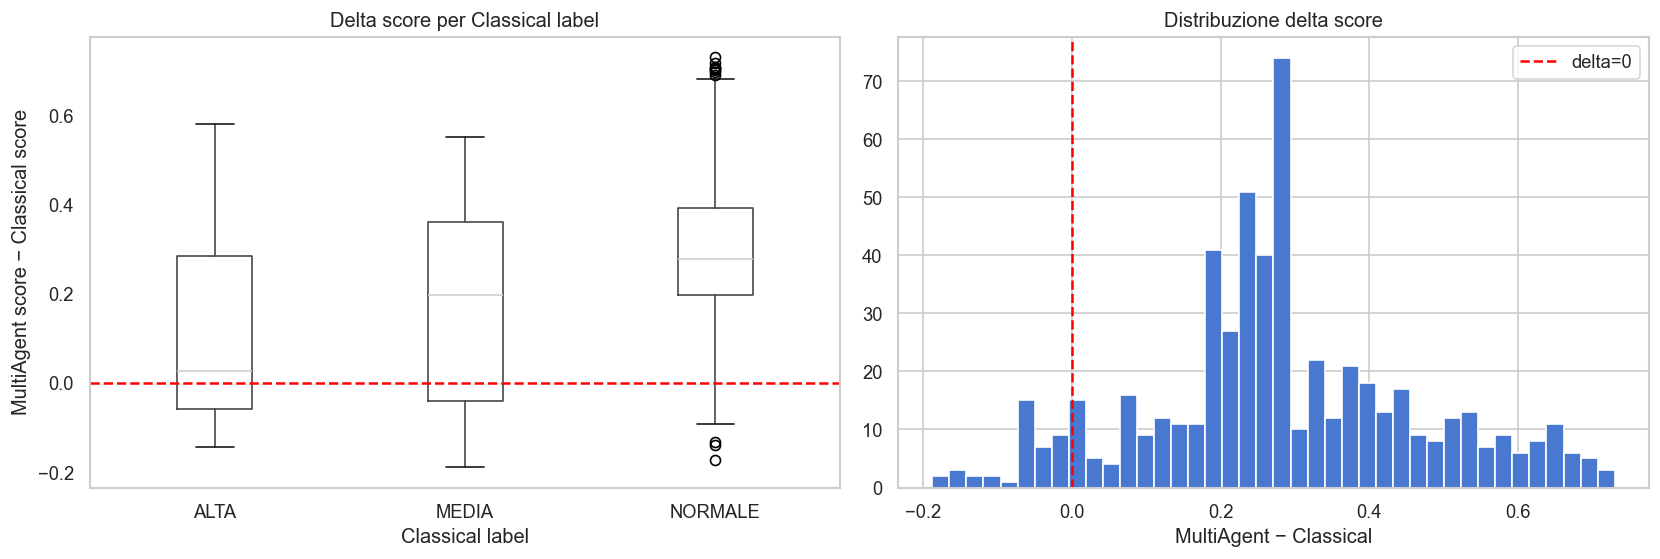

               count    mean     std     min     25%     50%     75%     max
anomaly_label                                                               
ALTA            17.0  0.1239  0.2193 -0.1421 -0.0578  0.0262  0.2856  0.5806
MEDIA           40.0  0.1911  0.2208 -0.1879 -0.0394  0.1985  0.3611  0.5509
NORMALE        510.0  0.2950  0.1753 -0.1732  0.1977  0.2792  0.3934  0.7301


In [6]:
df['delta'] = df['ensemble_score'] - df['anomaly_score']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delta per classical label
df.boxplot(column='delta', by='anomaly_label', ax=axes[0], grid=False)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Delta score per Classical label')
axes[0].set_xlabel('Classical label')
axes[0].set_ylabel('MultiAgent score − Classical score')

# Distribuzione delta
axes[1].hist(df['delta'], bins=40, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', label='delta=0')
axes[1].set_title('Distribuzione delta score')
axes[1].set_xlabel('MultiAgent − Classical')
axes[1].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()

print(df.groupby('anomaly_label')['delta'].describe().round(4))

## 6. Salvataggio comparison.csv

In [7]:
out = df.copy()
out['delta_score'] = (out['ensemble_score'] - out['anomaly_score']).round(4)
out['label_agree'] = out['anomaly_label'] == out['risk_label']
out_path = PROC / 'comparison_classical_vs_multiagent.csv'
out.to_csv(out_path, index=False)
print(f'Salvato: {out_path}')
print(f'Shape: {out.shape}')
print(f'Agreement: {out["label_agree"].mean():.1%}')
print(f'Pearson r: {pearson_r:.4f} | Spearman r: {spearman_r:.4f}')

Salvato: /Users/fil/Desktop/Machine learning condiviso /classical-vs-multiagent/data/processed/comparison_classical_vs_multiagent.csv
Shape: (567, 11)
Agreement: 84.0%
Pearson r: 0.3161 | Spearman r: 0.3625
